<a href="https://colab.research.google.com/github/musab855/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

Weeks 4–6 produced a validated ranking. This notebook turns it into the thing a human can actually use: a **content action playbook** — ranked actions with reason codes, an archetype -> action mapping, the decay/refresh insight, intended use and limits, human-review rules, cost/value thinking, light monitoring and retrain triggers, and an explicit list of what must never be automated.

**Skills loaded for this task:** `writing-honest-claims` (claim ladder: observed -> measured -> directional -> decision-support; never causal without a design) + `flyrank/flyrank-data` for the data.
**Claim vocabulary for every sentence below:** *observed, measured, directional, decision-support.* Nothing here is an experiment, so no sentence says *causes*, *proves*, or *will increase*.
**Sections, in order:** 1) ranked actions + reason codes (incl. the decay/refresh insight and the archetype -> action mapping) -> 2) intended use and limits -> 3) human review + the no-go list -> 4) monitoring / retrain triggers -> 5) exports for the paper -> self-check.
**Inputs:** the same March 2026 frame as Weeks 4–6 (cache-or-warehouse-scan, cache gitignored), and the committed starter CSV for the decay/refresh insight. Public-safe throughout: pseudonymized IDs only, no client names, URLs, or raw queries.

In [1]:
# ---- Setup -----------------------------------------------------------------
# Runs from the repo root (Colab badge clone or local clone). The token is read
# from Colab Secrets (same as Weeks 4-6), the environment, or a local .env file
# and is NEVER printed, stored, or written anywhere.
import os, sys, getpass, subprocess, importlib.util, shutil
from pathlib import Path

def find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "work").is_dir() and (p / "skills").is_dir():
            return p
    return None

root = find_repo_root(Path.cwd())
if root is None:
    if Path("/content").exists():
        dest = Path("/content/flyrank-ml-internship")   # Colab
    else:
        dest = Path.cwd() / "flyrank-ml-internship"     # local / other
    if (dest / "work").is_dir() and (dest / "skills").is_dir():
        print(f"repo folder already present - reusing it: {dest}")
        root = dest
    else:
        if dest.exists():
            shutil.rmtree(dest)          # leftover from an interrupted clone
        proc = subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/musab855/flyrank-ml-internship.git", str(dest)],
            capture_output=True, text=True)
        if proc.returncode != 0:
            print(proc.stdout); print(proc.stderr)
            raise RuntimeError(f"git clone failed (exit {proc.returncode}) - "
                               "read git's message above, fix it, re-run this cell.")
        root = dest
os.chdir(root)

missing = [p for p in ("duckdb", "huggingface_hub") if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    importlib.invalidate_caches()

def load_token():
    # Colab Secrets first (HF_TOKEN2, then HF_TOKEN), then env, then .env.
    try:
        from google.colab import userdata
        for key in ("HF_TOKEN2", "HF_TOKEN"):
            try:
                token = userdata.get(key)
                if token:
                    return token
            except Exception:
                pass
    except Exception:
        pass
    token = os.environ.get("HF_TOKEN")
    if token:
        return token
    env_file = Path(".env")
    if env_file.exists():
        for line in env_file.read_text().splitlines():
            if line.strip().startswith("HF_TOKEN"):
                return line.split("=", 1)[1].strip().strip(chr(34) + chr(39))
    return getpass.getpass("Paste your Hugging Face READ token (hf_...): ")

print("working directory:", Path.cwd())

working directory: C:\Users\Asus\Downloads\flyrank-ml-internship


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Four moves, in order: rebuild the validated scoring harness (same frame, same split, same seed as Weeks 5-6, so every receipt below matches what I already published), attach reason codes a reviewer can check row by row, bring in the decay/refresh insight, then map archetypes to actions and rank the queue.

In [2]:
# ---- Config ----------------------------------------------------------------
import json
%matplotlib inline
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

RANDOM_STATE = 42           # every random step in this notebook uses this one seed
N_FOLDS = 5
BASE_FEATURES = ["gsc_impressions_avg", "gsc_clicks_avg", "position_avg"]
IMPRESSIONS_THRESHOLD = 500  # Week-4 cutoff, unchanged
POSITION_THRESHOLD = 11      # Week-4 cutoff, unchanged
METRIC_ORDER = ["precision_at_10", "precision_at_20", "precision_at_50", "roc_auc", "avg_precision"]

# The receipts I check this run against - published in Weeks 4, 5 and 6.
PUBLISHED = {
    "pages": 140_599, "flagged": 1_074, "base_rate": 0.465,
    "rule": {"precision_at_10": 1.000, "precision_at_20": 0.950, "precision_at_50": 0.880},
    "rule_full": {"roc_auc": 0.609},
    "logistic_regression": {"roc_auc": 0.630},
    "random_forest": {"roc_auc": 0.654, "avg_precision": 0.583},
}

# Queue policies - written down BEFORE I look at any label in this notebook.
TIER_B_MIN_SCORE = 0.80      # forest OOF score needed to enter Tier B
TIER_B_MIN_IMPRESSIONS = 100 # ...and the visibility floor for it
REVIEW_MINUTES_PER_PAGE = 30 # reviewer-time assumption, not a measurement

print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"matplotlib {plt.matplotlib.__version__}")
Path("work/figures").mkdir(parents=True, exist_ok=True)   # figures are committed; queue CSV is not
print(f"random_state = {RANDOM_STATE} (fixed, so a rerun reproduces every table below)")
print("features:", BASE_FEATURES)
print(f"queue policies: Tier B score >= {TIER_B_MIN_SCORE}, Tier B impressions >= "
      f"{TIER_B_MIN_IMPRESSIONS}, review time assumption {REVIEW_MINUTES_PER_PAGE} min/page")

numpy 1.26.4 | pandas 2.1.1 | scikit-learn 1.3.1 | matplotlib 3.8.0
random_state = 42 (fixed, so a rerun reproduces every table below)
features: ['gsc_impressions_avg', 'gsc_clicks_avg', 'position_avg']
queue policies: Tier B score >= 0.8, Tier B impressions >= 100, review time assumption 30 min/page


In [3]:
# ---- Data: same SQL, same window, same filters as Weeks 4-6 ----------------
# March 2026. Features = days 1-15, label = days 16-31 (impressions fell).
# The heavy scan runs once and is cached (the cache is gitignored, never committed).
CACHE = Path("work/outputs/feature_frame_march_audit.csv")

if CACHE.exists():
    df = pd.read_csv(CACHE)
    print(f"Cache hit: {len(df):,} rows from {CACHE}")
else:
    HF_TOKEN = load_token()
    import duckdb
    con = duckdb.connect()
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
    rel = "hf://datasets/FlyRank/internship-warehouse"
    df = con.sql(f"""
    WITH daily_averages AS (
      SELECT content_hash_id, client_hash_id,
        AVG(CASE WHEN report_date < '2026-03-16' AND gsc_data_available THEN gsc_impressions ELSE NULL END) AS gsc_impressions_1to15,
        AVG(CASE WHEN report_date < '2026-03-16' AND gsc_data_available THEN gsc_clicks ELSE NULL END) AS gsc_clicks_1to15,
        AVG(CASE WHEN report_date < '2026-03-16' AND gsc_data_available THEN gsc_avg_position ELSE NULL END) AS position_1to15,
        AVG(CASE WHEN report_date >= '2026-03-16' AND gsc_data_available THEN gsc_impressions ELSE NULL END) AS gsc_impressions_16to31
      FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
      WHERE report_date >= '2026-03-01' AND report_date < '2026-04-01' AND gsc_data_available = TRUE
      GROUP BY content_hash_id, client_hash_id
    )
    SELECT content_hash_id AS content_id, client_hash_id,
      gsc_impressions_1to15 AS gsc_impressions_avg,
      gsc_clicks_1to15 AS gsc_clicks_avg,
      position_1to15 AS position_avg,
      gsc_impressions_16to31,
      (CASE WHEN gsc_impressions_16to31 IS NULL OR gsc_impressions_1to15 IS NULL THEN NULL
            WHEN gsc_impressions_16to31 < gsc_impressions_1to15 THEN 1 ELSE 0 END) AS is_declining_label
    FROM daily_averages
    """).df()
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE, index=False)
    print(f"Scanned the warehouse (March 2026): {len(df):,} rows -> cached at {CACHE}")

# Same filters as Weeks 4-6: undefined label or no position data -> dropped, not guessed.
n_before = len(df)
pos_nan, pos_zero, lab_nan = df["position_avg"].isna(), df["position_avg"] == 0, df["is_declining_label"].isna()
n_pos_nan, n_pos_zero = int(pos_nan.sum()), int(pos_zero.sum())
n_lab_nan_extra = int((lab_nan & ~pos_nan & ~pos_zero).sum())

df = df[~pos_nan & ~pos_zero & ~lab_nan].copy()
df["is_declining_label"] = df["is_declining_label"].astype(int)
df = df.sort_values("content_id", kind="stable").reset_index(drop=True)   # canonical order
assert len(df) + n_pos_nan + n_pos_zero + n_lab_nan_extra == n_before

# The label's own window column exists in the audit cache only so Week 6 could
# prove the harness detects leakage. This notebook never uses it - drop it now.
df = df.drop(columns=["gsc_impressions_16to31"])

df["ctr"] = np.where(df["gsc_impressions_avg"] > 0,
                     df["gsc_clicks_avg"] / df["gsc_impressions_avg"], 0.0)
flag = ((df["gsc_impressions_avg"] >= IMPRESSIONS_THRESHOLD) &
        (df["position_avg"] >= POSITION_THRESHOLD)).to_numpy()
df["rule_full"] = df["gsc_impressions_avg"] + 1e9 * flag     # reference ranks, no training
df["impressions_only"] = df["gsc_impressions_avg"]
base_rate = df["is_declining_label"].mean()

# Universe must match Weeks 4-6 exactly, or nothing downstream can be trusted.
assert len(df) == PUBLISHED["pages"], f"expected {PUBLISHED['pages']:,} pages, got {len(df):,}"
assert int(flag.sum()) == PUBLISHED["flagged"], f"expected {PUBLISHED['flagged']:,} flagged, got {int(flag.sum()):,}"
assert abs(base_rate - PUBLISHED["base_rate"]) < 0.0005, f"base rate {base_rate:.3f}"

print(f"Rows before filter: {n_before:,}  (dropped: {n_pos_nan:,} position NaN, "
      f"{n_pos_zero:,} position==0, {n_lab_nan_extra:,} undefined label)")
print(f"Modeling frame: {len(df):,} pages, {df['client_hash_id'].nunique()} clients")
print(f"Flagged by the Week-4 rule: {int(flag.sum()):,} ({flag.mean():.2%})   "
      f"Base rate (share declining): {base_rate:.3f}")
print(f"Total visibility in frame: {df['gsc_impressions_avg'].sum():,.0f} impressions/day")

Cache hit: 176,738 rows from work\outputs\feature_frame_march_audit.csv


Rows before filter: 176,738  (dropped: 24,757 position NaN, 1,306 position==0, 10,076 undefined label)
Modeling frame: 140,599 pages, 43 clients
Flagged by the Week-4 rule: 1,074 (0.76%)   Base rate (share declining): 0.465
Total visibility in frame: 8,895,076 impressions/day


In [4]:
# ---- The validated harness: client-grouped 5-fold, every page scored OOF once
def make_grouped_folds(frame, n_splits=N_FOLDS, seed=RANDOM_STATE):
    # Same construction as Weeks 5-6: each client sits in exactly one test fold.
    sizes = frame.groupby("client_hash_id").size()
    order = list(sizes.index)
    np.random.default_rng(seed).shuffle(order)
    fold_of_client, load = {}, [0] * n_splits
    for client in order:
        i = int(np.argmin(load)); fold_of_client[client] = i; load[i] += int(sizes[client])
    return frame["client_hash_id"].map(fold_of_client).astype(int)

df["fold_grouped"] = make_grouped_folds(df)
assert df.groupby("client_hash_id")["fold_grouped"].nunique().eq(1).all(), "a client spans two folds"

def rule_score(frame):
    f = (frame["gsc_impressions_avg"] >= IMPRESSIONS_THRESHOLD) & (frame["position_avg"] >= POSITION_THRESHOLD)
    return np.where(f, frame["gsc_impressions_avg"], 0.0)

def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores), kind="stable")[:k]
    return float(np.asarray(labels)[order].mean())

def metric_bundle(labels, scores):
    return {"precision_at_10": precision_at_k(labels, scores, 10),
            "precision_at_20": precision_at_k(labels, scores, 20),
            "precision_at_50": precision_at_k(labels, scores, 50),
            "roc_auc": roc_auc_score(labels, scores),
            "avg_precision": average_precision_score(labels, scores)}

def build_models():
    return {"logistic_regression": Pipeline([
                ("log", ColumnTransformer([("log", FunctionTransformer(np.log1p), [0, 1])],
                                          remainder="passthrough")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(class_weight="balanced", max_iter=1000,
                                             random_state=RANDOM_STATE))]),
            "random_forest": RandomForestClassifier(
                n_estimators=200, max_depth=10, min_samples_leaf=25,
                class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)}

y = df["is_declining_label"].to_numpy()
X = df[BASE_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
scores = {"rule": rule_score(df),
          "rule_full": df["rule_full"].to_numpy(),
          "impressions_only": df["impressions_only"].to_numpy(),
          "logistic_regression": np.zeros(len(df)),
          "random_forest": np.zeros(len(df))}

for f in range(N_FOLDS):
    test = (df["fold_grouped"] == f).to_numpy(); train = ~test
    models = build_models()
    for name in ("logistic_regression", "random_forest"):
        models[name].fit(X.iloc[train], y[train])
        scores[name][test] = models[name].predict_proba(X.iloc[test])[:, 1]
    print(f"fold {f}: {int(test.sum()):,} pages scored out-of-fold")

for name, s in scores.items():
    df[f"oof__{name}"] = s
pooled = {name: metric_bundle(y, s) for name, s in scores.items()}

receipt = pd.DataFrame(pooled).T.loc[:, METRIC_ORDER].round(3)
display(receipt)
print(f"base rate: {base_rate:.3f}   pages: {len(df):,}   clients: {df['client_hash_id'].nunique()}")

# Soft receipts against what I published in Weeks 4-6 (0.005 tolerance, same as Week 6).
rows = []
for method, wanted in PUBLISHED.items():
    if method in ("pages", "flagged", "base_rate"):
        continue
    for metric, target in wanted.items():
        got = pooled[method][metric]
        rows.append({"method": method, "metric": metric, "published": target,
                     "this_run": round(got, 3),
                     "check": "MATCH" if abs(got - target) <= 0.005 else "DIFF"})
receipts = pd.DataFrame(rows)
display(receipts)
n_diff = int((receipts["check"] == "DIFF").sum())
print(f"receipts: {len(receipts) - n_diff}/{len(receipts)} MATCH at +-0.005 "
      f"(libraries can move a digit; page/flag/base-rate asserts above are hard)")

fold 0: 32,790 pages scored out-of-fold


fold 1: 25,826 pages scored out-of-fold


fold 2: 26,662 pages scored out-of-fold


fold 3: 32,230 pages scored out-of-fold


fold 4: 23,091 pages scored out-of-fold


,precision_at_10,precision_at_20,precision_at_50,roc_auc,avg_precision
rule,1.0,0.95,0.88,0.505,0.469
rule_full,1.0,0.95,0.88,0.609,0.537
impressions_only,0.7,0.70,0.62,0.609,0.534
logistic_regression,0.7,0.70,0.78,0.630,0.571
random_forest,0.5,0.55,0.66,0.654,0.583


base rate: 0.465   pages: 140,599   clients: 43


,method,metric,published,this_run,check
0,rule,precision_at_10,1.000,1.000,MATCH
1,rule,precision_at_20,0.950,0.950,MATCH
2,rule,precision_at_50,0.880,0.880,MATCH
3,rule_full,roc_auc,0.609,0.609,MATCH
4,logistic_regression,roc_auc,0.630,0.630,MATCH
5,random_forest,roc_auc,0.654,0.654,MATCH
6,random_forest,avg_precision,0.583,0.583,MATCH


receipts: 7/7 MATCH at +-0.005 (libraries can move a digit; page/flag/base-rate asserts above are hard)


### What the receipts decide about the queue

Two findings from Weeks 5-6, both reproduced by the cell above, decide how this queue is shaped:

- **The rule owns the top of one queue.** `HIGH_VOLUME_POOR_POSITION` ranked by impressions reads **P@50 0.880** against a 0.465 base rate (P@10 1.000, P@20 0.950) — about 1.9x the base rate at K=50.
- **The forest owns the whole list.** Client-grouped out-of-fold ROC-AUC **0.654 (forest) vs 0.609 (`rule_full`)**, average precision 0.583 vs 0.537 — a measured lead of +0.045, not the flattering +0.149 a tie-flawed rule AUC would suggest.

So the queue is **tiered**: Tier A = the rule's flagged pages in impressions order (where precision was measured highest), Tier B = the forest's extreme tail on pages the rule does not flag (where the rule is silent by construction). The forest's score is a *rank*, never a calibrated probability, and the model rows are out-of-fold — every page scored by a model that never saw its client.

### Reason codes

A reason code is the one-line *why* a reviewer reads before touching a page. Every code below is computed from feature-window observables only (days 1–15) — the label is never an input, and no product flag or score enters the queue.

| Code | Fires when | What it means for the reviewer |
|---|---|---|
| `HIGH_VOLUME_POOR_POSITION` | impressions/day >= 500 **and** avg position >= 11 | Real visibility at stake, sitting off page one — the Week-4 rule's trigger (impressions verdict CONFIRMED; position cutoff kept as policy, verdict MIXED) |
| `NEAR_ZERO_CTR_IMPRESSIONS` | CTR < 0.001 with >= 500 impressions/day | The clicks do not match the impressions: verify the traffic is real demand before any content work |
| `BORDERLINE_THRESHOLD` | within 10% of either cutoff (450–550 impressions/day, or position 9.9–12.1) | One noisy day could move this page out of the queue — treat its place as provisional |
| `MODEL_HIGH_DECLINE_RANK` | forest OOF score >= 0.65 | The model also ranks this page high; corroboration, not proof (score is a rank, not a probability) |
| `PAGE_ONE_HIGH_STAKES` | >= 500 impressions/day with avg position better than 11 | Visibility worth protecting — decay watch, not a refresh trigger |
| `LOW_VOLUME_WATCH` | impressions/day < 500 | Below the rule's meaningful-volume floor: monitor only, never queued on volume alone |

In [5]:
# ---- Compute reason codes on the full frame --------------------------------
impr, pos, ctr = df["gsc_impressions_avg"], df["position_avg"], df["ctr"]
rf = df["oof__random_forest"]

df["rc_high_volume_poor_position"] = (impr >= IMPRESSIONS_THRESHOLD) & (pos >= POSITION_THRESHOLD)
df["rc_near_zero_ctr"] = (ctr < 0.001) & (impr >= IMPRESSIONS_THRESHOLD)
df["rc_borderline"] = ((impr >= 450) & (impr < 550)) | ((pos >= 9.9) & (pos <= 12.1))
df["rc_model_high_decline_rank"] = rf >= 0.65
df["rc_page_one_high_stakes"] = (impr >= IMPRESSIONS_THRESHOLD) & (pos < POSITION_THRESHOLD)
df["rc_low_volume_watch"] = impr < IMPRESSIONS_THRESHOLD

CODE_COLS = [c for c in df.columns if c.startswith("rc_")]
CODE_LABEL = {c: c[3:].upper() for c in CODE_COLS}

# Coverage: a page with no code would be a page nobody can explain.
counts = df[CODE_COLS].sum().astype(int)
assert (counts > 0).all(), "a reason code never fired - check its threshold"
base_cover = (impr >= IMPRESSIONS_THRESHOLD)
assert (df.loc[base_cover, ["rc_high_volume_poor_position", "rc_page_one_high_stakes"]].sum(axis=1) == 1).all()
assert df.loc[~base_cover, "rc_low_volume_watch"].all()
print("coverage check: every visible page has exactly one volume/position code; "
      "every below-floor page has LOW_VOLUME_WATCH")

df["reason_codes"] = df[CODE_COLS].apply(lambda r: "|".join(c for c in CODE_COLS if r[c]), axis=1)

code_table = pd.DataFrame({
    "fires_on_frame": counts.values,
    "share_of_frame": (counts / len(df)).map("{:.1%}".format).values,
    "fires_in_tier_A": df.loc[flag, CODE_COLS].sum().astype(int).values,
}, index=[CODE_LABEL[c] for c in CODE_COLS])
display(code_table.sort_values("fires_in_tier_A", ascending=False))
print(f"pages with >= 2 codes: {(df[CODE_COLS].sum(axis=1) >= 2).sum():,} "
      f"({(df[CODE_COLS].sum(axis=1) >= 2).mean():.1%}) - codes overlap on purpose")

coverage check: every visible page has exactly one volume/position code; every below-floor page has LOW_VOLUME_WATCH


,fires_on_frame,share_of_frame,fires_in_tier_A
HIGH_VOLUME_POOR_POSITION,1074,0.8%,1074
MODEL_HIGH_DECLINE_RANK,6683,4.8%,621
NEAR_ZERO_CTR,940,0.7%,572
BORDERLINE,10167,7.2%,170
PAGE_ONE_HIGH_STAKES,2031,1.4%,0
LOW_VOLUME_WATCH,137494,97.8%,0


pages with >= 2 codes: 16,898 (12.0%) - codes overlap on purpose


### The decay/refresh insight

**Different dataset, read the caveats first.** The warehouse frame carries no age or freshness columns, so this evidence comes from the committed starter CSV (30,000 pages, trailing-90-day metrics, ±10% `trend_direction` label, 32 clients). Different data and a different label from the queue above — so it is *context for the actions*, never a queue input. One refresh-time question: **do older or staler pages decline more?**

starter CSV: 30,000 pages, decline base rate 0.542 (label = trend_direction == 'down')


,decline_rate,pages,readable
age_bucket,,,
<180 days,0.627,12272,True
180-365 days,0.515,11368,True
365+ days,0.426,6360,True


,decline_rate,pages,readable
fresh_bucket,,,
0-30,0.511,20480,True
31-90,0.589,175,False
91-180,0.611,9171,True
181-365,0.467,169,False
365+,0.600,5,False


,pages,median_word_count,mean_age_days
trend_direction,,,
up,4388,2848.0,288.0
down,16262,2909.0,236.0


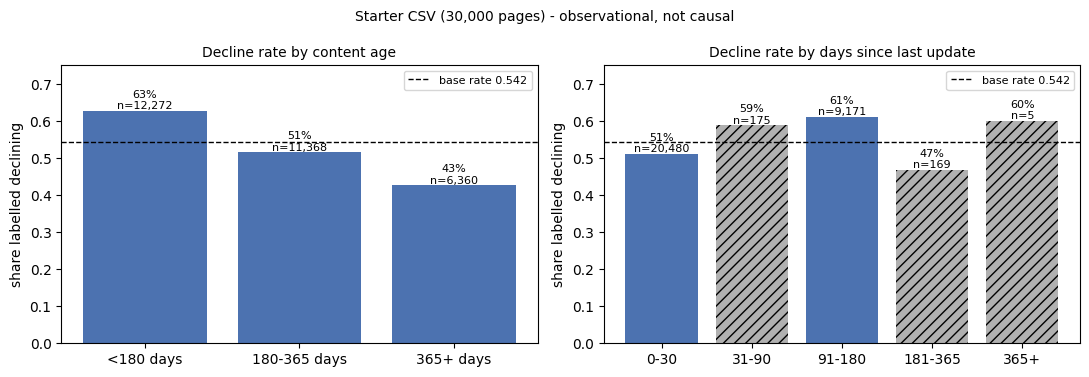

wrote work/figures/decay_refresh_insight.svg


In [6]:
# ---- Decay / refresh insight from the committed starter CSV ----------------
STARTER = Path("data/raw/content_refresh_anonymized.csv")
s = pd.read_csv(STARTER)
s["down"] = (s["trend_direction"] == "down").astype(int)
starter_base = s["down"].mean()
s["age_bucket"] = pd.cut(s["content_age_days"], [0, 180, 365, 730],
                         labels=["<180 days", "180-365 days", "365+ days"])
s["fresh_bucket"] = pd.cut(s["days_since_last_update"], [-1, 30, 90, 180, 365, 10**6],
                           labels=["0-30", "31-90", "91-180", "181-365", "365+"])
SMALL_N = 500   # the paper's own floor for analysis buckets

age_tbl = s.groupby("age_bucket", observed=True)["down"].agg(decline_rate="mean", pages="count")
fresh_tbl = s.groupby("fresh_bucket", observed=True)["down"].agg(decline_rate="mean", pages="count")
age_tbl["readable"] = age_tbl["pages"] >= SMALL_N
fresh_tbl["readable"] = fresh_tbl["pages"] >= SMALL_N
print(f"starter CSV: {len(s):,} pages, decline base rate {starter_base:.3f} "
      f"(label = trend_direction == 'down')")
display(age_tbl.round(3))
display(fresh_tbl.round(3))

by_trend = s.groupby("trend_direction").agg(
    pages=("content_id", "count"),
    median_word_count=("word_count", "median"),
    mean_age_days=("content_age_days", "mean")).round(0)
display(by_trend.loc[["up", "down"]])

# Figure: decline rate by age and by freshness (n < 500 bars hatched, not readable)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, tbl, title in ((axes[0], age_tbl, "Decline rate by content age"),
                       (axes[1], fresh_tbl, "Decline rate by days since last update")):
    colors = ["#4c72b0" if ok else "#b0b0b0" for ok in tbl["readable"]]
    bars = ax.bar(tbl.index.astype(str), tbl["decline_rate"], color=colors)
    for bar, row in zip(bars, tbl.itertuples()):
        ax.annotate(f"{row.decline_rate:.0%}\nn={row.pages:,}",
                    (bar.get_x() + bar.get_width() / 2, row.decline_rate),
                    ha="center", va="bottom", fontsize=8)
        if not row.readable:
            bar.set_hatch("///")
    ax.axhline(starter_base, color="black", ls="--", lw=1,
               label=f"base rate {starter_base:.3f}")
    ax.set_ylim(0, 0.75); ax.set_title(title, fontsize=10); ax.legend(fontsize=8)
    ax.set_ylabel("share labelled declining")
fig.suptitle("Starter CSV (30,000 pages) - observational, not causal", fontsize=10)
fig.tight_layout()
fig.savefig("work/figures/decay_refresh_insight.svg", bbox_inches="tight")
plt.show()
print("wrote work/figures/decay_refresh_insight.svg")

**What the starter CSV shows (observed, cross-sectional):**

- **Age reads clearly, and it cuts against "old content decays":** decline rate falls as content gets older — **62.7%** (<180 days, n=12,272) -> **51.5%** (180–365, n=11,368) -> **42.6%** (365+, n=6,360), against a 0.542 base rate. Mean age agrees: declining pages average **236 days** versus **288 days** for growing ones — in this slice the *younger* pages are the ones moving. Set against the FlyRank paper's cohort gap ("growing content is 20% younger", 184 vs 230 days), the direction is **reversed** — on the starter CSV the growing pages are the older ones — so **the paper's age gap does not reproduce here**, same status as the length gap below: different dataset, different label, different sample, not a refutation.
- **Freshness does not read.** Decline rate by `days_since_last_update` is non-monotonic (51.1% -> 58.9% -> 61.1% -> 46.7% -> 60.0%) and two of those buckets hold n=175, n=169 and n=5 — under the paper's own n>=500 floor (hatched bars above). **No clean "stale = decaying" pattern is observable here** — a negative result, reported as one.
- **The paper's length gap does not reproduce in this slice:** median word count is 2,909 for declining vs 2,848 for growing pages (~2%, not 37.6%). Different dataset, different label, different sample (the paper used 74,187 vs 45,272 warehouse pages) — so this is *not a refutation*, it is a finding that the length gap is not universal.

**What it changes about the actions:** age and freshness alone do not justify a refresh — the data will not support "this page is old, therefore rewrite it". The queue therefore ranks on *observed visibility at stake* (impressions, position), and freshness/age enters only as a **review prompt** (`page_one_high_stakes` = decay watch, `protect_and_monitor`). Every refresh recommendation below stays decision-support: *these pages look worth reviewing first*, never *refreshing will recover them*.

**Caveats that come with these numbers:** one snapshot of pages that already exist (content_age_days >= 90 by construction — survivorship), a ±10% trend label that can flip on a handful of impressions, cross-sectional, no intervention. Not evidence about the queue's own frame.

### Archetypes -> actions

Archetypes are **rule-based tags, not clusters** — deterministic buckets on two observables (impressions/day, avg position), named after I inspected what sits in each one. The guide's warning applies: they are a lens, not labels. Each archetype has a *standing* action; the queue tier and the reason codes then refine what happens to a page that is actually in the queue.

| Archetype | Rule | n (decline rate) | Standing action | Enters queue? |
|---|---|---|---|---|
| `high_volume_deep_position` | impr >= 500, pos >= 11 | 1,074 (0.780) | `review_first_refresh_and_ctr` — or `verify_traffic_first` when `NEAR_ZERO_CTR_IMPRESSIONS` fires | Tier A: **all** of them, impressions order |
| `page_one_high_stakes` | impr >= 500, pos < 11 | 2,031 (0.453) | `protect_and_monitor` — decay watch, not a refresh trigger | Only if forest score >= 0.80 (none did) |
| `mid_volume_opportunity` | impr >= 100, not above | 17,658 (0.544) | `monitor`, or `secondary_review` if the forest ranks it >= 0.80 | Tier B: **94** of them |
| `low_volume_long_tail` | impr < 100 | 119,836 (0.451) | `monitor_only` | Never — below the volume floor |

**Ranking rule.** Tier A first, ordered by impressions (the measured P@50 0.880 order), then Tier B ordered by the forest's out-of-fold score. A queue row's action is: Tier A + near-zero CTR -> `verify_traffic_first`; Tier A otherwise -> `review_first_refresh_and_ctr`; Tier B -> `secondary_review`; out of queue -> the standing action.

**Confidence.** `low` = borderline **or** near-zero CTR (the two ways this data can mislead a reviewer). `high` = far past both cutoffs (impr >= 2,000/day, position >= 20) with clean CTR. `medium` = the rest — and **no Tier B row is ever `high`**, because a forest rank from one month of one portfolio is not a high-confidence claim.

In [7]:
# ---- Archetypes, actions, confidence, tiers, ranking ------------------------
df["archetype"] = np.select(
    [df["rc_high_volume_poor_position"], df["rc_page_one_high_stakes"], impr >= 100],
    ["high_volume_deep_position", "page_one_high_stakes", "mid_volume_opportunity"],
    default="low_volume_long_tail")

arch_tbl = df.groupby("archetype").agg(
    pages=("content_id", "count"),
    decline_rate=("is_declining_label", "mean"),
    median_impressions=("gsc_impressions_avg", "median"),
    median_position=("position_avg", "median")).round(3)
arch_tbl["share_of_frame"] = (arch_tbl["pages"] / len(df)).map("{:.2%}".format)
display(arch_tbl.loc[["high_volume_deep_position", "page_one_high_stakes",
                      "mid_volume_opportunity", "low_volume_long_tail"]])

# Tier A: the rule's flag, impressions order (stable tie-break on content_id).
tier_a = df[flag].sort_values(["gsc_impressions_avg", "content_id"],
                              ascending=[False, True]).copy()
tier_a["tier"] = "A"
# Tier B: the forest's extreme tail on visible pages the rule does not flag.
tier_b_mask = (~flag) & (impr >= TIER_B_MIN_IMPRESSIONS) & (rf >= TIER_B_MIN_SCORE)
tier_b = df[tier_b_mask].sort_values(["oof__random_forest", "content_id"],
                                     ascending=[False, True]).copy()
tier_b["tier"] = "B"
nonflag_floor = rf[(~flag) & (impr >= TIER_B_MIN_IMPRESSIONS)]
print(f"Tier B threshold {TIER_B_MIN_SCORE} sits above the "
      f"{(nonflag_floor < TIER_B_MIN_SCORE).mean():.1%} percentile of non-flagged scores "
      f"(n={len(tier_b):,} pages enter Tier B)")

queue = pd.concat([tier_a, tier_b], ignore_index=True)
queue["rank"] = np.arange(1, len(queue) + 1)

def action_for(row):
    if row["tier"] == "A":
        return "verify_traffic_first" if row["rc_near_zero_ctr"] else "review_first_refresh_and_ctr"
    if row["tier"] == "B":
        return "secondary_review"
    return {"page_one_high_stakes": "protect_and_monitor"}.get(row["archetype"], "monitor_only")

def confidence_for(row):
    if row["rc_borderline"] or row["rc_near_zero_ctr"]:
        return "low"
    if row["tier"] == "B":
        return "medium"                      # a rank is never high confidence
    if row["gsc_impressions_avg"] >= 2000 and row["position_avg"] >= 20:
        return "high"
    return "medium"

def wrong_if(row):
    if row["rc_near_zero_ctr"]:
        return (f"CTR under 0.001 on {row['gsc_impressions_avg']:,.0f} impressions/day - the "
                "traffic may be bots or indexing artefacts rather than demand; verify the "
                "traffic source before anyone edits this page")
    if row["rc_borderline"]:
        return ("within 10% of a cutoff - one noisy day of data could put this page back on "
                "the other side of the line")
    if row["tier"] == "B":
        return ("the forest's score is an out-of-fold rank from one month of one portfolio, "
                "not a probability - the page may simply hold steady")
    return ("the label is an impressions drop, so high-volume pages partly regress to the mean; "
            "and nothing here measures whether a refresh helps - only that visibility is at stake")

queue["action"] = queue.apply(action_for, axis=1)
queue["confidence"] = queue.apply(confidence_for, axis=1)
queue["wrong_if"] = queue.apply(wrong_if, axis=1)

print(f"\nQueue: {len(queue):,} pages  (Tier A {len(tier_a):,} + Tier B {len(tier_b):,})")
display(queue.groupby(["tier", "action"]).size().to_frame("pages"))
display(queue.groupby(["tier", "confidence"]).size().to_frame("pages"))
display(queue.groupby("tier")["is_declining_label"].agg(
    pages="count", declining_rate="mean").round(3))
print(f"queue labelled declining: {queue['is_declining_label'].mean():.3f} "
      f"(frame base rate {base_rate:.3f})")

top_cols = ["rank", "tier", "content_id", "archetype", "action", "confidence",
            "gsc_impressions_avg", "position_avg", "ctr", "oof__random_forest",
            "reason_codes", "wrong_if"]
print("\nTop 20 of the ranked queue:")
display(queue.head(20)[top_cols].rename(columns={
    "gsc_impressions_avg": "impr/day", "position_avg": "pos",
    "oof__random_forest": "forest_oof"}).round(3))

,pages,decline_rate,median_impressions,median_position,share_of_frame
archetype,,,,,
high_volume_deep_position,1074,0.780,783.033,30.059,0.76%
page_one_high_stakes,2031,0.453,745.067,4.005,1.44%
mid_volume_opportunity,17658,0.544,178.533,5.783,12.56%
low_volume_long_tail,119836,0.451,6.786,9.000,85.23%


Tier B threshold 0.8 sits above the 99.5% percentile of non-flagged scores (n=94 pages enter Tier B)

Queue: 1,168 pages  (Tier A 1,074 + Tier B 94)


pages
tier action                             
A    review_first_refresh_and_ctr    502
     verify_traffic_first            572
B    secondary_review                 94

pages
tier confidence       
A    high           20
     low           673
     medium        381
B    low            14
     medium         80

,pages,declining_rate
tier,,
A,1074,0.780
B,94,0.777


queue labelled declining: 0.780 (frame base rate 0.465)

Top 20 of the ranked queue:


,rank,tier,content_id,archetype,action,confidence,impr/day,pos,ctr,forest_oof,reason_codes,wrong_if
0,1,A,content_e8a52cf3d5988c07,high_volume_deep_position,review_first_refresh_and_ctr,medium,9544.867,16.019,0.002,0.569,rc_high_volume_poor_position,"the label is an impressions drop, so high-volu..."
1,2,A,content_36e53e9c707674fc,high_volume_deep_position,review_first_refresh_and_ctr,high,7327.267,33.354,0.001,0.683,rc_high_volume_poor_position|rc_model_high_dec...,"the label is an impressions drop, so high-volu..."
2,3,A,content_3df3f32f3fd58dea,high_volume_deep_position,review_first_refresh_and_ctr,high,5602.733,24.501,0.001,0.646,rc_high_volume_poor_position,"the label is an impressions drop, so high-volu..."
3,4,A,content_5e1c049f62e33b11,high_volume_deep_position,review_first_refresh_and_ctr,medium,4862.667,18.233,0.001,0.630,rc_high_volume_poor_position,"the label is an impressions drop, so high-volu..."
4,5,A,content_82e35c4845e6c391,high_volume_deep_position,verify_traffic_first,low,4677.933,18.270,0.000,0.708,rc_high_volume_poor_position|rc_near_zero_ctr|...,"CTR under 0.001 on 4,678 impressions/day - the..."
5,6,A,content_df47d1b976106de4,high_volume_deep_position,review_first_refresh_and_ctr,high,4422.800,25.222,0.001,0.660,rc_high_volume_poor_position|rc_model_high_dec...,"the label is an impressions drop, so high-volu..."
6,7,A,content_559cdd76da9306de,high_volume_deep_position,verify_traffic_first,low,4161.200,37.866,0.000,0.746,rc_high_volume_poor_position|rc_near_zero_ctr|...,"CTR under 0.001 on 4,161 impressions/day - the..."
7,8,A,content_bdf60c86117079be,high_volume_deep_position,verify_traffic_first,low,4018.467,31.046,0.000,0.691,rc_high_volume_poor_position|rc_near_zero_ctr|...,"CTR under 0.001 on 4,018 impressions/day - the..."
8,9,A,content_9fff53e827550f9d,high_volume_deep_position,review_first_refresh_and_ctr,high,3764.667,22.357,0.005,0.701,rc_high_volume_poor_position|rc_model_high_dec...,"the label is an impressions drop, so high-volu..."
9,10,A,content_573804af4f4fa09f,high_volume_deep_position,verify_traffic_first,low,3529.867,29.927,0.000,0.614,rc_high_volume_poor_position|rc_near_zero_ctr,"CTR under 0.001 on 3,530 impressions/day - the..."


### Reading the queue

- **1,168 pages are actionable: Tier A = 1,074 (every flagged page, impressions order), Tier B = 94 (forest score >= 0.80 on visible pages the rule ignores).** Both tiers sit near a 78% declining rate — printed above against the 0.465 frame base rate, i.e. about 1.7x.
- **Confidence is mostly `low` (673 of Tier A's 1,074) and that is the honest headline.** 572 rows are low because CTR is under 0.001 — the exact weakness Week 4 found (53% of flagged pages) — and 101 more because they sit within 10% of a cutoff. Only 20 rows clear `high`. A queue this uncertain does not get automated; it gets a verification step first.
- **The archetypes split the inventory 1.0 / 2.0 / 17.7 / 119.8 thousand pages**, and their decline rates do the arguing: `high_volume_deep_position` at 0.780 versus `page_one_high_stakes` at 0.453 — *below* the base rate. Queuing page-one pages for refresh would spend reviewer hours on pages that, in this frame, decline less than average.
- **The queue is narrow where it matters:** the 1,074 Tier A pages are 0.76% of the frame but hold 1,082,306 impressions/day — **12.2%** of all measured visibility (8,895,076/day).

,K,declining_in_batch,measured_P@K,impr/day_at_stake,share_of_frame_visibility,review_hours_at_30min
0,10,10,1.000,51912,0.6%,5
1,20,19,0.950,83414,0.9%,10
2,50,44,0.880,158626,1.8%,25
3,100,85,0.850,259830,2.9%,50
4,200,169,0.845,414670,4.7%,100
5,500,397,0.794,722517,8.1%,250
6,1074,838,0.780,1082306,12.2%,537
7,1168,911,0.780,1111611,12.5%,584


,pages_per_week,pages_per_month,expected_declining_in_month,impr/day_in_those_pages,review_hours_per_month,months_to_clear_queue
0,10,40,36,135740,20,29.2
1,20,80,68,222006,40,14.6
2,50,200,169,414670,100,5.8


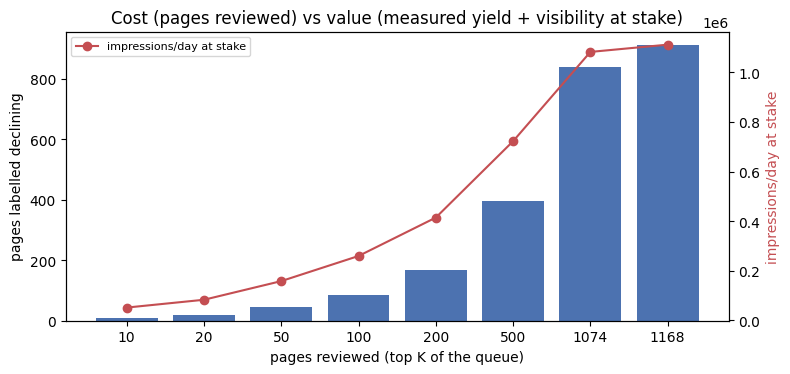

wrote work/figures/capacity_vs_yield.svg


In [8]:
# ---- Cost / value: what a batch of reviews is worth -------------------------
TOTAL_IMPR = df["gsc_impressions_avg"].sum()
rows = []
for k in (10, 20, 50, 100, 200, 500, len(tier_a), len(queue)):
    sub = queue.head(k)
    rows.append({
        "K": k,
        "declining_in_batch": int(sub["is_declining_label"].sum()),
        "measured_P@K": round(sub["is_declining_label"].mean(), 3),
        "impr/day_at_stake": int(np.round(sub["gsc_impressions_avg"].sum())),
        "share_of_frame_visibility": f"{sub['gsc_impressions_avg'].sum() / TOTAL_IMPR:.1%}",
        "review_hours_at_30min": int(np.ceil(k * REVIEW_MINUTES_PER_PAGE / 60)),
    })
capacity = pd.DataFrame(rows)
display(capacity)

rows = []
for per_week in (10, 20, 50):
    k = per_week * 4                      # one month of reviews at this pace
    sub = queue.head(k)
    rows.append({
        "pages_per_week": per_week,
        "pages_per_month": k,
        "expected_declining_in_month": int(sub["is_declining_label"].sum()),
        "impr/day_in_those_pages": int(np.round(sub["gsc_impressions_avg"].sum())),
        "review_hours_per_month": int(k * REVIEW_MINUTES_PER_PAGE / 60),
        "months_to_clear_queue": round(len(queue) / k, 1),
    })
pace = pd.DataFrame(rows)
display(pace)

fig, ax = plt.subplots(figsize=(8, 4))
ks = [10, 20, 50, 100, 200, 500, len(tier_a), len(queue)]
sub_counts = [int(queue.head(k)["is_declining_label"].sum()) for k in ks]
sub_impr = [int(queue.head(k)["gsc_impressions_avg"].sum()) for k in ks]
ax.bar([str(k) for k in ks], sub_counts, color="#4c72b0", label="declining pages in that batch")
ax.set_xlabel("pages reviewed (top K of the queue)"); ax.set_ylabel("pages labelled declining")
ax2 = ax.twinx()
ax2.plot([str(k) for k in ks], sub_impr, color="#c44e52", marker="o",
         label="impressions/day at stake")
ax2.set_ylabel("impressions/day at stake", color="#c44e52")
ax.set_title("Cost (pages reviewed) vs value (measured yield + visibility at stake)")
lines = ax.get_lines()[:1] + [ax2.lines[0]]
ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig("work/figures/capacity_vs_yield.svg", bbox_inches="tight")
plt.show()
print("wrote work/figures/capacity_vs_yield.svg")

### Cost/value, stated plainly

- **Cost is a capacity number, not a dollar figure.** The notebook assumes 30 minutes per page (`REVIEW_MINUTES_PER_PAGE`, an assumption I wrote down, not a measurement): the top-50 batch is ~25 review-hours — one focused week for one reviewer — while clearing the whole 1,168-page queue at 20 pages/week takes ~14.6 months. **The queue is a standing backlog, not a one-shot project**, which is exactly why Tier A is ranked and Tier B exists only as a 94-page tail.
- **Value is visibility at stake plus measured yield, not revenue.** Top-50 carries 158,626 impressions/day (~4.8M per 30 days) with 44 of 50 pages measured declining; Tier A as a whole carries 12.2% of the frame's visibility. Impressions are *exposure*, not money — no conversion or revenue column exists here, so the playbook never prices an action in currency.
- **The asymmetry that sets the rules:** a false positive costs ~30 minutes of a human's time; a false negative costs continued visibility loss on a page that was already at stake (Week-1 framing, unchanged). That asymmetry is why the queue is aggressive about *volume* and conservative about *acting* — and why `verify_traffic_first` exists at all.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [9]:
# ---- The scope facts the prose below cites ---------------------------------
scope = {
    "data_window": "2026-03-01 .. 2026-03-31 (features days 1-15, label days 16-31)",
    "pages_scored": len(df),
    "clients": int(df["client_hash_id"].nunique()),
    "base_rate_declining": round(base_rate, 3),
    "validation": f"client-grouped {N_FOLDS}-fold, every page scored out-of-fold once",
    "features": ", ".join(BASE_FEATURES),
    "rule_P@50": round(pooled["rule"]["precision_at_50"], 3),
    "forest_roc_auc": round(pooled["random_forest"]["roc_auc"], 3),
    "rule_full_roc_auc": round(pooled["rule_full"]["roc_auc"], 3),
    "queue_pages": len(queue),
    "tier_A": len(tier_a),
    "tier_B": len(tier_b),
    "queue_declining_rate": round(queue["is_declining_label"].mean(), 3),
    "random_state": RANDOM_STATE,
}
display(pd.Series(scope, dtype=object).to_frame("value"))

,value
data_window,"2026-03-01 .. 2026-03-31 (features days 1-15, ..."
pages_scored,140599
clients,43
base_rate_declining,0.465
validation,"client-grouped 5-fold, every page scored out-o..."
features,"gsc_impressions_avg, gsc_clicks_avg, position_avg"
rule_P@50,0.88
forest_roc_auc,0.654
rule_full_roc_auc,0.609
queue_pages,1168


**Intended use.** One thing: **order a human reviewer's work.** Given a month of search data, the playbook says *these pages deserve eyes first, in this order, for these reasons, with these known ways to be wrong*. Users: the SEO specialist or content strategist who owns the review queue. The unit of output is a *page to review*, never a *change to ship*.

**Why decision-support is the ceiling, not a style choice.** The label is "impressions fell in days 16–31", the design is a single cross-section of one month and one portfolio, and nothing here ran an intervention. Per the claim ladder, the strongest sentences this work supports are: *we observed*, *was measured at*, *directional*, *these pages look worth reviewing first*.

**Limits — where the playbook stops being valid:**

1. **One month, one portfolio, pseudonymized.** March 2026, 43 clients. Nothing is measured on another month, another year, or another portfolio — the generalization is untested.
2. **The label is a proxy.** An impressions drop is not "the page is bad": regression to the mean sits inside every high-volume pick (flagged explicitly in `wrong_if`), and a page can hold steady and still be worthless.
3. **The position cutoff is policy, not evidence.** Week-4's verdict on `position >= 11` was MIXED (decline rate 47.2% -> 48.0% -> 45.9% -> 42.5%, non-monotonic). It is kept because it encodes a business assumption, and this notebook inherits it unchanged.
4. **Half the top queue may not be human traffic.** 572 of the 1,074 Tier A pages have CTR < 0.001; this data cannot separate bots from real demand — which is why verification precedes editing.
5. **Not causal, not predictive of Google.** No sentence here says a refresh will recover a page or that "the algorithm rewards" anything. It ranks review candidates.
6. **Client-concentrated by construction.** One client owns 74.7% of flagged pages (Week 5), so any per-client reading of the queue inherits that skew.
7. **Scores are ranks, not probabilities.** The forest's out-of-fold score orders pages; it is not calibrated, so "0.80" does not mean "80% chance of declining".

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [10]:
# ---- Audit the top of the queue the reviewer will actually see -------------
def audit(block, name):
    return {
        "block": name, "pages": len(block),
        "near_zero_ctr": int(block["rc_near_zero_ctr"].sum()),
        "borderline": int(block["rc_borderline"].sum()),
        "low_confidence": int((block["confidence"] == "low").sum()),
        "clients": int(block["client_hash_id"].nunique()),
        "largest_client_share": f"{block['client_hash_id'].value_counts(normalize=True).iloc[0]:.0%}",
        "declining_rate": round(block["is_declining_label"].mean(), 3),
    }

display(pd.DataFrame([audit(queue.head(20), "top 20"),
                      audit(queue.head(50), "top 50"),
                      audit(queue.head(100), "top 100")]))

review_cols = ["rank", "content_id", "action", "confidence", "rc_near_zero_ctr",
               "rc_borderline", "gsc_impressions_avg", "position_avg", "wrong_if"]
print("The 10 pages a reviewer opens first, with the checks that must happen before any edit:")
display(queue.head(10)[review_cols].rename(columns={
    "rc_near_zero_ctr": "near_zero_ctr?", "rc_borderline": "borderline?",
    "gsc_impressions_avg": "impr/day", "position_avg": "pos"}).round(3))

assert queue.head(50)["rc_near_zero_ctr"].sum() == 33, "top-50 low-CTR count changed - recheck prose"
assert queue.head(50)["client_hash_id"].nunique() == 3
print("audited numbers: top-50 = 33 near-zero-CTR rows, 3 clients (largest 82%) - "
      "both trigger section 4's monitoring flags")

,block,pages,near_zero_ctr,borderline,low_confidence,clients,largest_client_share,declining_rate
0,top 20,20,12,0,12,2,85%,0.95
1,top 50,50,33,0,33,3,82%,0.88
2,top 100,100,70,0,70,4,83%,0.85


The 10 pages a reviewer opens first, with the checks that must happen before any edit:


,rank,content_id,action,confidence,near_zero_ctr?,borderline?,impr/day,pos,wrong_if
0,1,content_e8a52cf3d5988c07,review_first_refresh_and_ctr,medium,False,False,9544.867,16.019,"the label is an impressions drop, so high-volu..."
1,2,content_36e53e9c707674fc,review_first_refresh_and_ctr,high,False,False,7327.267,33.354,"the label is an impressions drop, so high-volu..."
2,3,content_3df3f32f3fd58dea,review_first_refresh_and_ctr,high,False,False,5602.733,24.501,"the label is an impressions drop, so high-volu..."
3,4,content_5e1c049f62e33b11,review_first_refresh_and_ctr,medium,False,False,4862.667,18.233,"the label is an impressions drop, so high-volu..."
4,5,content_82e35c4845e6c391,verify_traffic_first,low,True,False,4677.933,18.270,"CTR under 0.001 on 4,678 impressions/day - the..."
5,6,content_df47d1b976106de4,review_first_refresh_and_ctr,high,False,False,4422.800,25.222,"the label is an impressions drop, so high-volu..."
6,7,content_559cdd76da9306de,verify_traffic_first,low,True,False,4161.200,37.866,"CTR under 0.001 on 4,161 impressions/day - the..."
7,8,content_bdf60c86117079be,verify_traffic_first,low,True,False,4018.467,31.046,"CTR under 0.001 on 4,018 impressions/day - the..."
8,9,content_9fff53e827550f9d,review_first_refresh_and_ctr,high,False,False,3764.667,22.357,"the label is an impressions drop, so high-volu..."
9,10,content_573804af4f4fa09f,verify_traffic_first,low,True,False,3529.867,29.927,"CTR under 0.001 on 3,530 impressions/day - the..."


audited numbers: top-50 = 33 near-zero-CTR rows, 3 clients (largest 82%) - both trigger section 4's monitoring flags


**Human-review rules — every queued page, before any content work.** The first four are the guide's look-alike checks: a drop is not automatically a decline.

1. **Traffic is real?** If `NEAR_ZERO_CTR_IMPRESSIONS` fired: confirm the impressions are human demand (analytics sessions, query mix, no indexing incident) — *before* any content work. 572 of 1,074 Tier A pages need this step.
2. **Is it decline, or a look-alike?** Check the four alternatives: **consolidation** (did a sibling URL absorb the demand?), **seasonality** (did the whole site/topic move?), **SERP/CTR loss** (impressions and position steady but clicks fell?), **noise** (volume too low to mean anything?).
3. **Is it borderline?** If `BORDERLINE_THRESHOLD` fired, say so out loud when reviewing — its queue position is provisional.
4. **Is it one client's problem?** Top-50 is 82% one client. Read within-client before generalizing across the portfolio.
5. **Only then: what is the content action?** Rewrite, expand, retarget metadata, consolidate, or leave it — a human decision, informed by the archetype's standing action, never issued by the queue.
6. **Write down what would make the call wrong** — the `wrong_if` column is written per row for exactly this.

**The no-go list — what is never automated, in this or any future version:**

- **Never publish, edit, or delete a page from a score.** The queue proposes; a person decides. No auto-publishing, no auto-rollback.
- **Never auto-merge, canonicalize, or prune.** Consolidation decisions need URL-level context this data deliberately does not contain.
- **Never act on `low_volume_long_tail` pages** (119,836 pages, below the volume floor) — no automated action of any kind.
- **Never run `verify_traffic_first` pages through a content action** — verification gates editing, always.
- **Never retrain and deploy unattended.** Section 4 triggers a *human* re-audit; models do not replace themselves in the queue.
- **Never use the queue as a performance metric for a team or client** — it measures where visibility is at stake, not who is doing well.
- **Never state causally that a refresh "will" improve anything**, and never present a score as a probability of decline.
- **Never export client names, URLs, domains, or raw queries** — the queue carries pseudonymous IDs only, and that is a permanent rule, not a notebook setting.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [11]:
# ---- Trigger table: live values where this run can measure them -------------
top50 = queue.head(50)
low_ctr_share = float(top50["rc_near_zero_ctr"].mean())
client_share = float(top50["client_hash_id"].value_counts(normalize=True).iloc[0])
rule_p50 = pooled["rule"]["precision_at_50"]
forest_auc = pooled["random_forest"]["roc_auc"]
base_drift = abs(base_rate - PUBLISHED["base_rate"])

def status(ok): return "OK" if ok else "FIRING"

triggers = pd.DataFrame([
    {"trigger": "queue_precision@50 on new labels",
     "rule": "re-audit thresholds, then retrain, if P@50 < 0.70 on the next scored month",
     "current": f"{rule_p50:.3f}", "status": status(rule_p50 >= 0.70)},
    {"trigger": "grouped ROC-AUC (forest)",
     "rule": "retrain + re-check features if AUC < 0.60 on a fresh client-grouped run",
     "current": f"{forest_auc:.3f}", "status": status(forest_auc >= 0.60)},
    {"trigger": "base-rate drift",
     "rule": "if |new base rate - 0.465| > 0.05: check seasonality and label definition BEFORE retraining",
     "current": f"{base_rate:.3f} (delta {base_drift:.3f})", "status": status(base_drift <= 0.05)},
    {"trigger": "near-zero-CTR share of top 50",
     "rule": "if > 60%: traffic verification is mandatory before any content action (gates editing)",
     "current": f"{low_ctr_share:.0%} ({int(top50['rc_near_zero_ctr'].sum())}/50)",
     "status": "FIRING (by design - verification gate stays on)"},
    {"trigger": "single-client share of top 50",
     "rule": "if > 60%: warn the reviewer that the queue is client-concentrated; read within-client",
     "current": f"{client_share:.0%}", "status": "FIRING (warn reviewer, queue stays as-is)"},
    {"trigger": "frame freshness",
     "rule": "score the most recent complete month; if the frame is not it, re-run this notebook",
     "current": "2026-03 (fixed evaluation window)", "status": "CHECK AT NEXT RUN"},
    {"trigger": "queue overlap month over month",
     "rule": "if < 50% of last month's top-50 returns: re-rank, then re-audit the reason codes",
     "current": "first run - no prior queue", "status": "CHECK AT NEXT RUN"},
    {"trigger": "feature drift (median impressions/day)",
     "rule": "if the frame median shifts > 20% vs the prior month: re-check thresholds before trusting scores",
     "current": "first run - no prior frame", "status": "CHECK AT NEXT RUN"},
    {"trigger": "position cutoff verdict",
     "rule": "Week-4 verdict was MIXED; if it flips on new data, re-audit `position >= 11` (policy, not evidence)",
     "current": "MIXED (Week 4)", "status": "MONITOR"},
], columns=["trigger", "rule", "current", "status"])
display(triggers)

,trigger,rule,current,status
0,queue_precision@50 on new labels,"re-audit thresholds, then retrain, if P@50 < 0...",0.880,OK
1,grouped ROC-AUC (forest),retrain + re-check features if AUC < 0.60 on a...,0.654,OK
2,base-rate drift,if |new base rate - 0.465| > 0.05: check seaso...,0.465 (delta 0.000),OK
3,near-zero-CTR share of top 50,if > 60%: traffic verification is mandatory be...,66% (33/50),FIRING (by design - verification gate stays on)
4,single-client share of top 50,if > 60%: warn the reviewer that the queue is ...,82%,"FIRING (warn reviewer, queue stays as-is)"
5,frame freshness,score the most recent complete month; if the f...,2026-03 (fixed evaluation window),CHECK AT NEXT RUN
6,queue overlap month over month,if < 50% of last month's top-50 returns: re-ra...,first run - no prior queue,CHECK AT NEXT RUN
7,feature drift (median impressions/day),if the frame median shifts > 20% vs the prior ...,first run - no prior frame,CHECK AT NEXT RUN
8,position cutoff verdict,Week-4 verdict was MIXED; if it flips on new d...,MIXED (Week 4),MONITOR


**How the queue goes stale, in plain words.** The numbers above were measured on March 2026 with a fixed split and a fixed seed; the world is not fixed. Three things age the playbook: **the data window** (a queue scored on March cannot speak to October — freshness is a hard trigger, not a preference), **the relationships** (impressions->decline held at 0.780 in Tier A this month; if a fresh month's P@50 drops under 0.70, the rule's thresholds are the first suspect, the model second), and **the label itself** (if the base rate moves more than 5 points, something changed in what "declining" means — seasonality or a definition bug — and retraining would happily learn the bug).

**Two triggers are already FIRING and both are by design:** 66% of the top 50 is near-zero-CTR (verification gate stays on for every content action) and 82% of the top 50 is one client (the reviewer is warned to read within-client). Firing is the honest state — the alternative would be hiding known weaknesses.

**Order of operations when a trigger fires:** (1) re-score the newest month, (2) re-audit the *thresholds and verdicts* (Week-4's MIXED position cutoff first), (3) only then retrain — and retraining still means "a human re-runs this notebook and reads the receipts", never an unattended redeploy. The receipts (`playbook_metrics.json`) are written every run precisely so the next run can diff against them.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

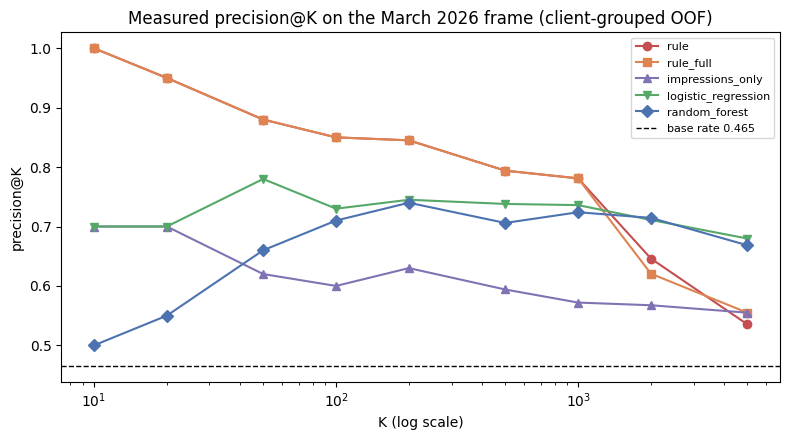

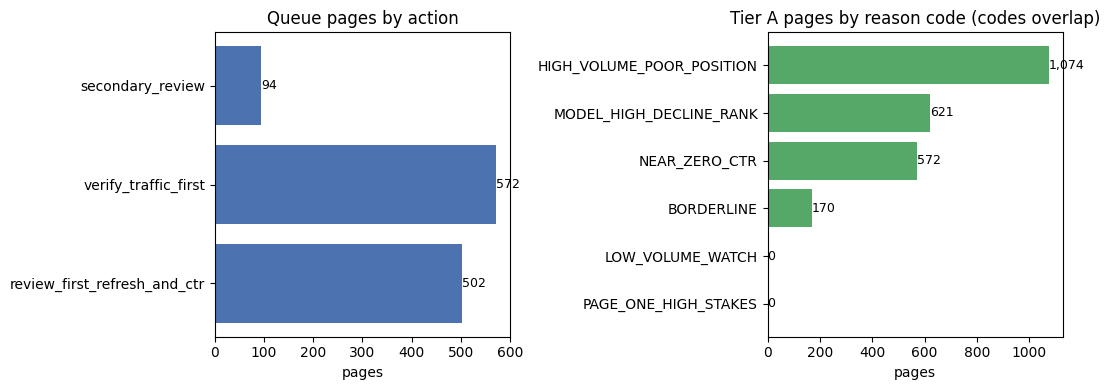

wrote work/figures/queue_yield_curve.svg and work/figures/queue_action_mix.svg


In [12]:
# ---- Figures for the queue itself -------------------------------------------
# P@K curve: the rule's top-of-queue lead vs the forest's whole-list lead.
ks = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
fig, ax = plt.subplots(figsize=(8, 4.5))
style = {"rule": ("#c44e52", "o"), "rule_full": ("#dd8452", "s"),
         "impressions_only": ("#8172b3", "^"), "logistic_regression": ("#55a868", "v"),
         "random_forest": ("#4c72b0", "D")}
for name, (color, marker) in style.items():
    ax.plot(ks, [precision_at_k(y, scores[name], k) for k in ks], color=color,
            marker=marker, label=name)
ax.axhline(base_rate, color="black", ls="--", lw=1, label=f"base rate {base_rate:.3f}")
ax.set_xscale("log"); ax.set_xlabel("K (log scale)"); ax.set_ylabel("precision@K")
ax.set_title("Measured precision@K on the March 2026 frame (client-grouped OOF)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("work/figures/queue_yield_curve.svg", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = ["review_first_refresh_and_ctr", "verify_traffic_first", "secondary_review"]
counts_a = queue["action"].value_counts()
counts_a = counts_a.reindex([o for o in order if o in counts_a.index])
axes[0].barh(counts_a.index, counts_a.values, color="#4c72b0")
for i, v in enumerate(counts_a.values):
    axes[0].annotate(f"{v:,}", (v, i), va="center", fontsize=9)
axes[0].set_title("Queue pages by action"); axes[0].set_xlabel("pages")

rc_counts = df.loc[flag, CODE_COLS].sum().sort_values()
axes[1].barh([CODE_LABEL[c] for c in rc_counts.index], rc_counts.values, color="#55a868")
for i, v in enumerate(rc_counts.values):
    axes[1].annotate(f"{v:,}", (v, i), va="center", fontsize=9)
axes[1].set_title("Tier A pages by reason code (codes overlap)")
axes[1].set_xlabel("pages")
fig.tight_layout()
fig.savefig("work/figures/queue_action_mix.svg", bbox_inches="tight")
plt.show()
print("wrote work/figures/queue_yield_curve.svg and work/figures/queue_action_mix.svg")

In [13]:
# ---- Exports: the queue CSV (gitignored) + metrics JSON (committed) ---------
OUT, FIG = Path("work/outputs"), Path("work/figures")
OUT.mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

queue["rule_flag"] = ((queue["gsc_impressions_avg"] >= IMPRESSIONS_THRESHOLD) &
                      (queue["position_avg"] >= POSITION_THRESHOLD))
export_cols = ["rank", "tier", "content_id", "client_hash_id", "archetype", "action",
               "confidence", "reason_codes", "wrong_if", "rule_flag",
               "oof__logistic_regression", "oof__random_forest",
               "gsc_impressions_avg", "gsc_clicks_avg", "position_avg", "ctr",
               "is_declining_label"]
queue_out = queue[export_cols].rename(columns={
    "oof__logistic_regression": "lr_oof_score",
    "oof__random_forest": "rf_oof_score",
    "gsc_impressions_avg": "impressions_per_day", "gsc_clicks_avg": "clicks_per_day",
    "position_avg": "avg_position", "is_declining_label": "declined_label_16to31"})
queue_path = OUT / "action_queue.csv"
queue_out.to_csv(queue_path, index=False)

def _jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    return str(o)

metrics = {
    "assignment": "ML-10 content action playbook",
    "frame": {"window": "2026-03-01..2026-03-31", "features": BASE_FEATURES,
              "label": "impressions days 16-31 < days 1-15", "pages": len(df),
              "clients": int(df["client_hash_id"].nunique()),
              "base_rate": round(base_rate, 4), "flagged_by_rule": int(flag.sum()),
              "split": f"client-grouped {N_FOLDS}-fold OOF", "random_state": RANDOM_STATE},
    "receipts": {m: {k: round(v, 4) for k, v in b.items()} for m, b in pooled.items()},
    "queue": {"total": len(queue), "tier_a": len(tier_a), "tier_b": len(tier_b),
              "declining_rate": round(queue["is_declining_label"].mean(), 4),
              "action_mix": queue["action"].value_counts().to_dict(),
              "confidence_mix": queue["confidence"].value_counts().to_dict(),
              "archetype_mix": df["archetype"].value_counts().to_dict(),
              "archetype_decline_rate": df.groupby("archetype")["is_declining_label"]
                                          .mean().round(4).to_dict(),
              "reason_codes_in_tier_a": {CODE_LABEL[c]: int(df.loc[flag, c].sum())
                                         for c in CODE_COLS},
              "top50_near_zero_ctr": int(queue.head(50)["rc_near_zero_ctr"].sum()),
              "top50_clients": int(queue.head(50)["client_hash_id"].nunique())},
    "capacity_assumptions": {"review_minutes_per_page": REVIEW_MINUTES_PER_PAGE,
                             "tier_b_min_score": TIER_B_MIN_SCORE,
                             "tier_b_min_impressions": TIER_B_MIN_IMPRESSIONS},
    "decay_refresh_starter_csv": {
        "note": "different dataset + label from the queue; context only, never a queue input",
        "pages": len(s), "decline_base_rate": round(starter_base, 4),
        "by_age_bucket": {str(k): {"decline_rate": round(v["decline_rate"], 4),
                                   "pages": int(v["pages"])}
                          for k, v in age_tbl.iterrows()},
        "by_freshness_bucket": {str(k): {"decline_rate": round(v["decline_rate"], 4),
                                         "pages": int(v["pages"]),
                                         "readable": bool(v["readable"])}
                                for k, v in fresh_tbl.iterrows()}},
    "triggers": triggers.to_dict(orient="records"),
    "figures": ["queue_yield_curve.svg", "queue_action_mix.svg",
                "decay_refresh_insight.svg", "capacity_vs_yield.svg"],
    "exports": {"queue_csv": str(queue_path),
                "note": "queue CSV is gitignored by design (CI leak-guard); regenerate with this notebook"},
}
metrics_path = OUT / "playbook_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2, default=_jsonable), encoding="utf-8")

print("Exports written:")
for p in [queue_path, metrics_path] + [FIG / f for f in metrics["figures"]]:
    print(f"  {p}  ({p.stat().st_size:,} bytes)")

# Verification: queue CSV must be gitignored (CI leak-guard); JSON + figures must not be.
print("\nGit status of each export (regeneration note for the paper):")
for target, want_ignored in ((queue_path, True), (metrics_path, False),
                             (FIG / "queue_yield_curve.svg", False)):
    ignored = subprocess.run(["git", "check-ignore", "-q", str(target)],
                             capture_output=True).returncode == 0
    verdict = "OK" if ignored == want_ignored else "CHECK"
    print(f"  {'gitignored' if ignored else 'committable'} | {target}: {verdict}")

Exports written:


  work\outputs\action_queue.csv  (510,578 bytes)
  work\outputs\playbook_metrics.json  (6,117 bytes)
  work\figures\queue_yield_curve.svg  (52,081 bytes)
  work\figures\queue_action_mix.svg  (54,710 bytes)
  work\figures\decay_refresh_insight.svg  (57,075 bytes)
  work\figures\capacity_vs_yield.svg  (43,884 bytes)

Git status of each export (regeneration note for the paper):
  gitignored | work\outputs\action_queue.csv: OK
  committable | work\outputs\playbook_metrics.json: OK


  committable | work\figures\queue_yield_curve.svg: OK


**What the paper builds on next week (all paths repo-relative):**

| File | Contents | In git? |
|---|---|---|
| `work/outputs/action_queue.csv` | the ranked queue: rank, tier, pseudonymous IDs, archetype, action, confidence, reason codes, `wrong_if`, both OOF scores, observables, label | no — regenerated by this notebook (CI blocks data CSVs) |
| `work/outputs/playbook_metrics.json` | the receipts: frame facts, full metric table, queue mix, decay/refresh tables, trigger states | **yes** |
| `work/figures/queue_yield_curve.svg` | precision@K for all five methods + base rate (the results figure) | **yes** |
| `work/figures/queue_action_mix.svg` | queue pages by action, Tier A pages by reason code | **yes** |
| `work/figures/decay_refresh_insight.svg` | decline rate by age and freshness on the starter CSV, small-n buckets hatched | **yes** |
| `work/figures/capacity_vs_yield.svg` | pages reviewed vs declining pages found vs visibility at stake | **yes** |

Suggested caption discipline for the paper: every figure carries its frame (*March 2026, client-grouped out-of-fold, n=140,599, base rate 0.465*) and ladder words only — observed, measured, directional, decision-support.

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] Ranked actions with reason codes, per row and tabled (section 1)
- [x] Archetype -> action mapping with rules, counts, and decline rates inspected (section 1)
- [x] Decay/refresh insight included, with its different-dataset caveats and a negative result reported (section 1)
- [x] Intended use, users, and seven named limits where the playbook stops being valid (section 2)
- [x] Human-review rules incl. the four look-alike checks, plus an explicit no-go list of what must never be automated (section 3)
- [x] Monitoring / retrain triggers with thresholds, live current values, and firing states — including two already firing by design (section 4)
- [x] Cost/value thinking: capacity, review-time assumption, visibility at stake, and the false-positive/negative asymmetry (section 1)
- [x] Exports written to `work/outputs/` (queue CSV gitignored, metrics JSON committed) and figures to `work/figures/` (committed) — verified with git inside the notebook (section 5)
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (pseudonymous IDs only; aggregates everywhere else)
- [x] Claims use careful words: observed, measured, directional, decision-support — no *proves*, *causes*, *will increase*
- [x] Claim-word scan of this notebook's markdown: every hit is self-referential — the notebook naming the words it refuses to use (title, self-check) and the no-go sentence stating what it will *not* claim. None of them is a claim; a scanner that never fired would be as untrustworthy as a leakage test that never fired.
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.